In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier

import shap

import warnings
warnings.filterwarnings("ignore")

In [27]:
df = pd.read_csv("ai_student_impact_dataset (1).csv")

In [28]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [30]:
df['Burnout_Risk_Level'].value_counts()

,count
Burnout_Risk_Level,
Medium,21144
Low,16369
High,12487


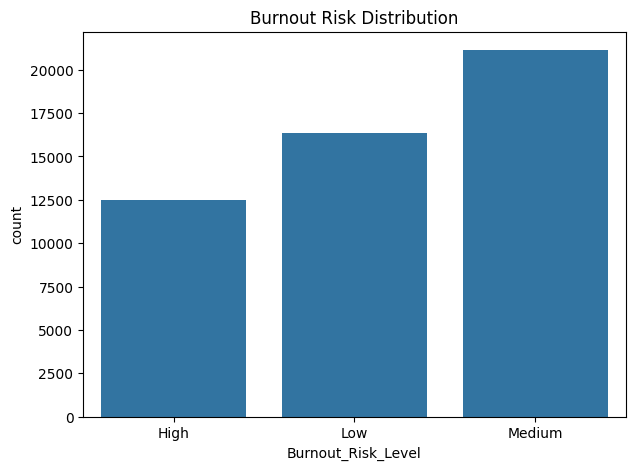

In [31]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Burnout_Risk_Level'
)

plt.title("Burnout Risk Distribution")

plt.show()

In [32]:
df = df.drop(columns=['Student_ID'])

In [33]:
target_encoder = LabelEncoder()

df['Burnout_Risk_Level'] = target_encoder.fit_transform(
    df['Burnout_Risk_Level']
)

df['Burnout_Risk_Level'].value_counts()

,count
Burnout_Risk_Level,
2,21144
1,16369
0,12487


In [34]:
categorical_cols = df.select_dtypes(include='object').columns

encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    encoders[col] = le

In [35]:
df.head()

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,2,3,2.418,23.31,0,1,1,True,8.13,5,1,6,2.393,86.44,0
1,3,2,3.821,1.12,3,0,5,False,16.65,3,1,9,3.696,69.39,1
2,1,0,3.398,21.26,4,1,2,False,10.35,5,2,9,3.499,73.93,2
3,1,3,3.789,1.82,0,2,4,False,15.23,2,1,2,4.000,63.58,2
4,4,4,3.635,9.29,1,0,4,False,12.55,4,1,4,3.798,100.00,2


In [36]:
df['Paid_Subscription'] = df['Paid_Subscription'].astype(int)

In [37]:
X = df.drop(columns=['Burnout_Risk_Level'])

y = df['Burnout_Risk_Level']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40000, 14)
X_test shape: (10000, 14)
y_train shape: (40000,)
y_test shape: (10000,)


In [40]:
df['Burnout_Risk_Binary'] = df[
    'Burnout_Risk_Level'
].apply(
    lambda x: 1 if x == 0 else 0
)

In [41]:
df['Burnout_Risk_Binary'].value_counts()

,count
Burnout_Risk_Binary,
0,37513
1,12487


In [42]:
X = df.drop(columns=[
    'Burnout_Risk_Level',
    'Burnout_Risk_Binary'
])

y = df['Burnout_Risk_Binary']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
negative = y_train.value_counts()[0]
positive = y_train.value_counts()[1]

scale_pos_weight = negative / positive

print(scale_pos_weight)

3.004004004004004


In [45]:
xgb_balanced = XGBClassifier(
    n_estimators=700,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

In [46]:
xgb_balanced.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=700, n_jobs=None,
              num_parallel_tree=None, ...)

In [47]:
y_pred_balanced = xgb_balanced.predict(X_test)

In [48]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_balanced)
)

Accuracy: 0.7729


In [49]:
print(
    classification_report(
        y_test,
        y_pred_balanced
    )
)

              precision    recall  f1-score   support

           0       0.86      0.83      0.85      7503
           1       0.54      0.59      0.56      2497

    accuracy                           0.77     10000
   macro avg       0.70      0.71      0.71     10000
weighted avg       0.78      0.77      0.78     10000



In [50]:
y_probs = xgb_balanced.predict_proba(X_test)[:,1]

In [51]:
auc = roc_auc_score(y_test, y_probs)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.7865399027947224


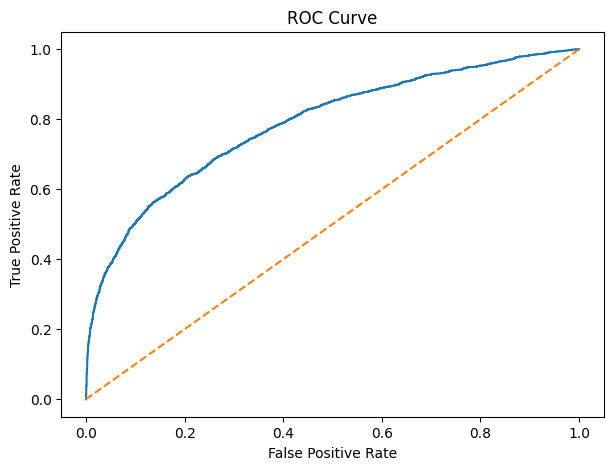

In [52]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probs
)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [53]:
importance = xgb_balanced.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
3,Weekly_GenAI_Hours,0.194313
1,Year_of_Study,0.101406
9,Perceived_AI_Dependency,0.092426
10,Institutional_Policy,0.071864
2,Pre_Semester_GPA,0.060811
8,Traditional_Study_Hours,0.059798
12,Post_Semester_GPA,0.058917
13,Skill_Retention_Score,0.056916
11,Anxiety_Level_During_Exams,0.053679
7,Paid_Subscription,0.051646


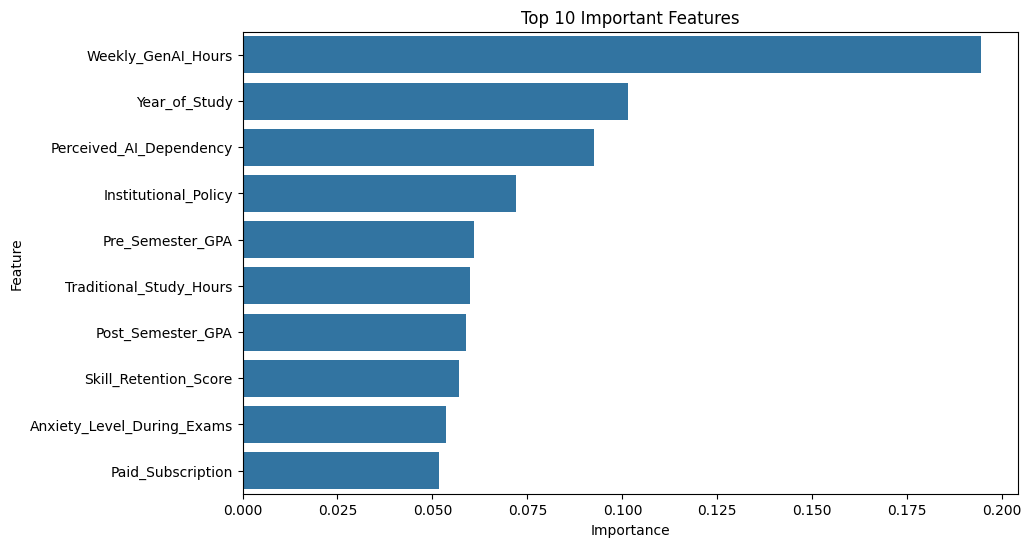

In [54]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

In [55]:
explainer = shap.TreeExplainer(xgb_balanced)

In [56]:
shap_values = explainer.shap_values(X_test)

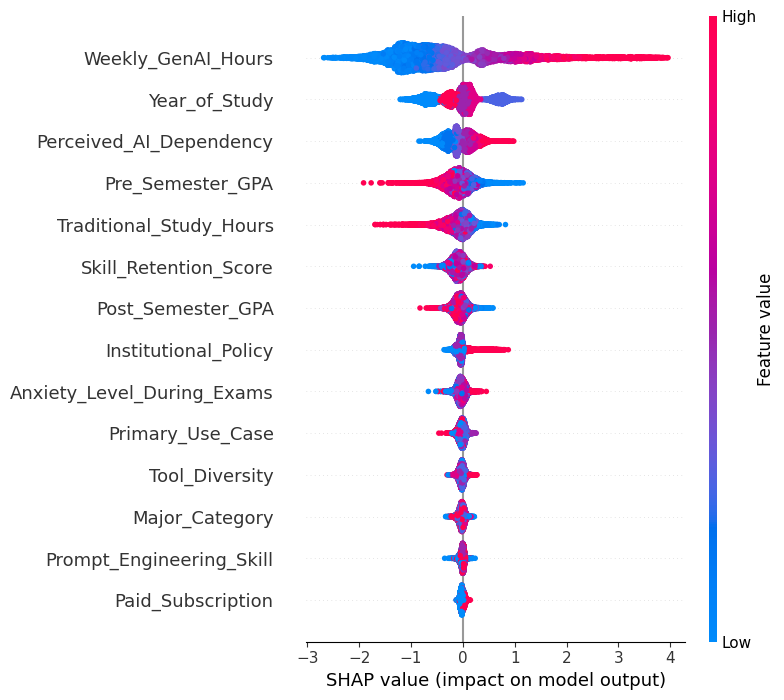

In [57]:
shap.summary_plot(
    shap_values,
    X_test
)